<h1>IMPORTAÇÕES</h1>


In [55]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler



<h1>TRATAMENTO DE DADOS</h1>


In [56]:
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


<h1>NORMALIZAÇÃO DOS DADOS</h1>


In [57]:
values = df[3003858507].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)
for i in range(5):
    print(df_normalized[i])

[0.17729522]
[0.13194063]
[0.16025289]
[0.26058274]
[0.39692139]


In [58]:
df["Normalized"] = df_normalized

In [59]:
auto_arima(
    df["Normalized"],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   45
Model:               SARIMAX(2, 0, 2)   Log Likelihood                   9.565
Date:                Mon, 15 Jan 2024   AIC                             -7.129
Time:                        09:33:29   BIC                              3.710
Sample:                    06-01-2019   HQIC                            -3.088
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0783      0.022      3.604      0.000       0.036       0.121
ar.L1          1.7063      0.111     15.418      0.000       1.489       1.923
ar.L2         -0.8801      0.129     -6.843      0.000      -1.132      -0.628
ma.L1         -1.3641      0.233     -5.860      0.000      -1.820      -0.908
ma.L2          0.3861      0.210      1.842      0.066      -0.025       0.797
sigma2         0.0356      0.009      3.748      0.000       0.017       0.054
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 2.67
Prob(Q):                              0.83   Prob(JB):                         0.26
Heteroskedasticity (H):               0.52   Skew:                             0.59
Prob(H) (two-sided):                  0.22   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [60]:
train = df.iloc[:40]
test = df.iloc[40:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train["Normalized"], order=(2, 0, 2), seasonal_order=(1, 1, 5, 12))
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.01868D-02    |proj g|=  1.29880D-01

At iterate    5    f=  5.39995D-02    |proj g|=  1.29887D-01


 This problem is unconstrained.



At iterate   10    f=  3.22695D-03    |proj g|=  7.91095D-02

At iterate   15    f= -1.25614D-02    |proj g|=  2.17506D-01

At iterate   20    f= -2.28648D-02    |proj g|=  2.09821D-01

At iterate   25    f= -2.39298D-02    |proj g|=  1.30918D-02

At iterate   30    f= -2.56696D-02    |proj g|=  7.38091D-02

At iterate   35    f= -2.71801D-02    |proj g|=  5.65207D-01

At iterate   40    f= -2.85854D-02    |proj g|=  3.46552D-02

At iterate   45    f= -2.85940D-02    |proj g|=  5.90088D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   11     45     67      1     0     0   5.901D-04  -2.859D-02
  F =  -2.85940234264


   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


In [61]:
start = len(train)
end = len(train) + len(test) - 1
normalized_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

normalized_future_predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

for i in range(len(normalized_predictions)):
    print(
        f"predição={normalized_predictions[i]}, esperado={df['Normalized'][i]}, erro={np.abs((normalized_predictions[i]-df['Normalized'][i])/(df['Normalized'][i]))*100}%"
    )

predição=0.0, esperado=0.1772952171522815, erro=100.0%
predição=8.51359594277362e-09, esperado=0.13194062671797693, erro=99.99999354740375%
predição=1.1329133018315831e-08, esperado=0.16025288620120945, erro=99.99999293046554%
predição=1.0824699074569332e-08, esperado=0.26058273776800445, erro=99.99999584596463%
predição=1.1194590069115417e-08, esperado=0.3969213853765806, erro=99.99999717964552%
predição=1.4660222253312719e-08, esperado=0.9389774601429358, erro=99.9999984387035%
predição=3.982645289101709e-08, esperado=0.49065420560747663, erro=99.99999188298959%
predição=2.9254525042406973e-08, esperado=1.0, erro=99.9999970745475%
predição=3.397641292685548e-08, esperado=0.6192963166575042, erro=99.9999945137066%
predição=1.1390037338706162e-08, esperado=0.7166025288620121, erro=99.99999841055022%
predição=-5.048429233728102e-09, esperado=0.12286970863111599, erro=100.00000410876635%
predição=-4.044873940501362e-08, esperado=0.19571192963166575, erro=100.00002066748792%
predição=0.17

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

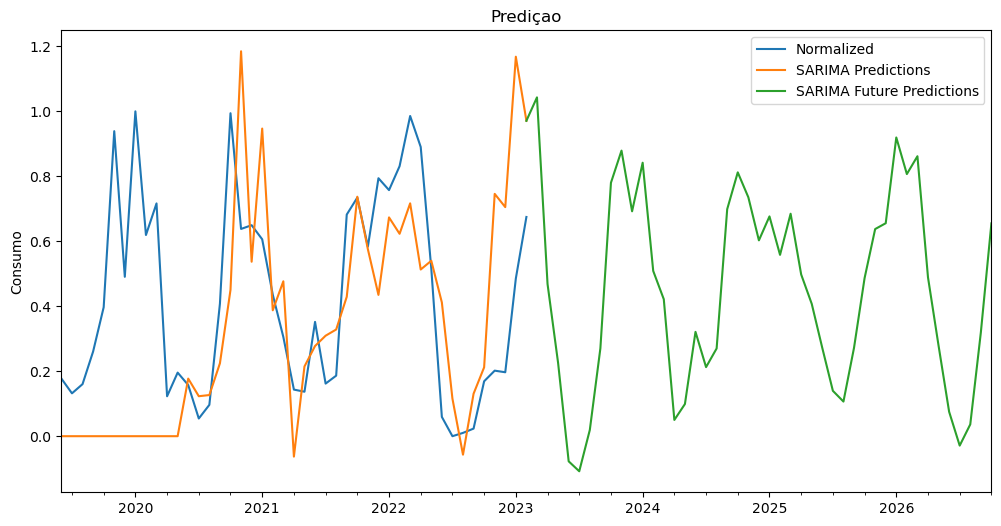

In [62]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["Normalized"].plot(legend=True, figsize=(12, 6), title=title)
normalized_predictions.plot(legend=True)
normalized_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [63]:
values = normalized_predictions.values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df["inversed"] = inversed

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

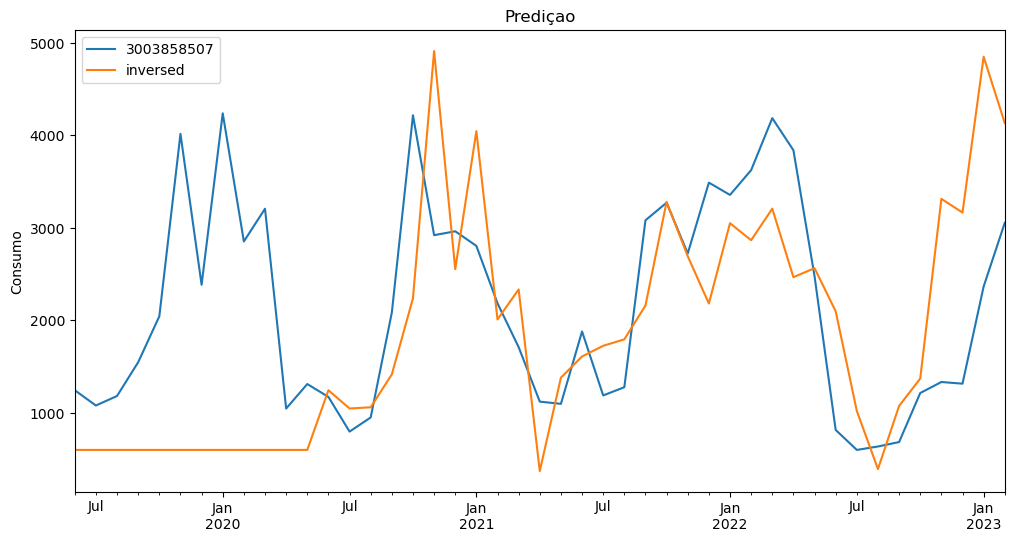

In [64]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
ax2 = df["inversed"].plot(legend=True, figsize=(12, 6), title=title)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [65]:
model = SARIMAX(
    df[3003858507].astype(float), order=(1, 0, 0), seasonal_order=(5, 0, 4, 12)
)
results = model.fit()

predictions = results.predict(start=0, end=end + 1, dynamic=False, typ="levels").rename(
    "SARIMA Predictions"
)

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.25909D+00    |proj g|=  9.25155D-02

At iterate    5    f=  8.24301D+00    |proj g|=  1.37426D-02

At iterate   10    f=  8.23818D+00    |proj g|=  2.20369D-03

At iterate   15    f=  8.23814D+00    |proj g|=  1.76517D-03

At iterate   20    f=  8.23808D+00    |proj g|=  5.53350D-04

At iterate   25    f=  8.23807D+00    |proj g|=  4.73519D-04

At iterate   30    f=  8.23805D+00    |proj g|=  6.97055D-04

At iterate   35    f=  8.23804D+00    |proj g|=  9.22990D-04

At iterate   40    f=  8.23786D+00    |proj g|=  4.02589D-03

At iterate   45    f=  8.23456D+00    |proj g|=  1.19001D-02

At iterate   50    f=  8.23265D+00    |proj g|=  4.01679D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

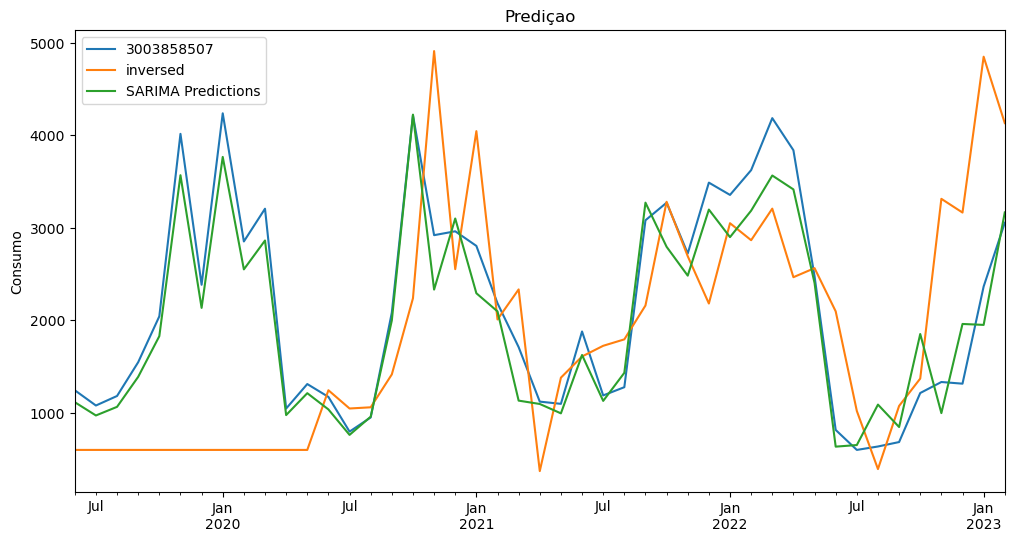

In [66]:
predictions = predictions.shift(-1)

title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
ax2 = df["inversed"].plot(legend=True, figsize=(12, 6), title=title)
predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [67]:
values = normalized_future_predictions.values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df["inversed"] = inversed

In [68]:
model = SARIMAX(
    df[3003858507].astype(float), order=(1, 0, 0), seasonal_order=(5, 0, 4, 12)
)
results = model.fit()

predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.25909D+00    |proj g|=  9.25155D-02


 This problem is unconstrained.



At iterate    5    f=  8.24301D+00    |proj g|=  1.37426D-02

At iterate   10    f=  8.23818D+00    |proj g|=  2.20369D-03

At iterate   15    f=  8.23814D+00    |proj g|=  1.76517D-03

At iterate   20    f=  8.23808D+00    |proj g|=  5.53350D-04

At iterate   25    f=  8.23807D+00    |proj g|=  4.73519D-04

At iterate   30    f=  8.23805D+00    |proj g|=  6.97055D-04

At iterate   35    f=  8.23804D+00    |proj g|=  9.22990D-04

At iterate   40    f=  8.23786D+00    |proj g|=  4.02589D-03

At iterate   45    f=  8.23456D+00    |proj g|=  1.19001D-02

At iterate   50    f=  8.23265D+00    |proj g|=  4.01679D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

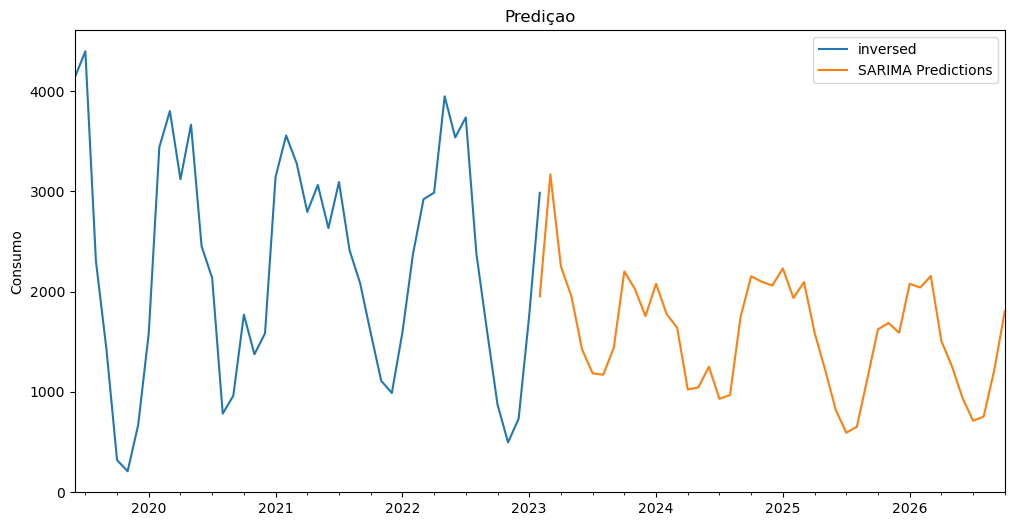

In [69]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["inversed"].plot(legend=True, figsize=(12, 6), title=title)
predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

<h1>Z Score</h1>


In [70]:
df

,3003858507,3001084033,3011373971,3001449459,3011504476,Normalized,inversed
idx,,,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0,0.177295,4133.361571
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0,0.131941,4395.501351
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0,0.160253,2305.531720
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0,0.260583,1420.580971
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0,0.396921,319.503513
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0,0.938977,208.092724
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0,0.490654,670.586055
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0,1.000000,1584.887859
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0,0.619296,3439.532002


In [71]:
df.drop("Normalized", inplace=True, axis=1)
df.drop("inversed", inplace=True, axis=1)

In [83]:
std_scaler = StandardScaler

values = df[3003858507].values
values = values.reshape((len(values), 1))

std = std_scaler.fit(values)

TypeError: fit() missing 1 required positional argument: 'X'